## 1. LSTM for Predicting the Next Daily Step Count

We use a small sequence of daily step counts. The model looks at a fixed number of previous days and predicts the number of steps for the next day.

In [1]:
# Install TensorFlow if it is not already installed:
# !pip install tensorflow

import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Example daily step counts
steps = np.array([
    4000, 4200, 4300, 4100, 4500,
    4700, 4600, 4800, 5000, 4900,
    5200, 5400, 5300, 5500, 5700
], dtype=np.float32)

# Use the previous 3 days to predict the next day
window_size = 3

X, y = [], []
for i in range(len(steps) - window_size):
    X.append(steps[i:i + window_size])
    y.append(steps[i + window_size])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

# LSTM expects: (samples, time_steps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

print("X shape:", X.shape)
print("y shape:", y.shape)
print("First input window:", X[0].flatten())
print("First target:", y[0])


X shape: (12, 3, 1)
y shape: (12,)
First input window: [4000. 4200. 4300.]
First target: 4100.0


In [2]:
# Build a simple Keras LSTM model
model = Sequential([
    LSTM(32, input_shape=(window_size, 1)),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")

model.summary()

# Train the model
history = model.fit(
    X, y,
    epochs=100,
    batch_size=4,
    verbose=0
)

print("Final training loss:", history.history["loss"][-1])


C:\Users\devds\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 32)                  │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

Final training loss: 24925354.0


In [3]:
# Predict the next day's step count
recent_days = np.array([5400, 5300, 5500], dtype=np.float32)
recent_days = recent_days.reshape(1, window_size, 1)

prediction = model.predict(recent_days, verbose=0)

print(f"Recent steps: {recent_days.flatten().astype(int).tolist()}")
print(f"Predicted next-day steps: {prediction[0, 0]:.0f}")


Recent steps: [5400, 5300, 5500]
Predicted next-day steps: 2


### Why use an LSTM here?

An LSTM can learn patterns across several time steps. For a fitness app, the previous few days of activity can provide useful context when estimating the next day's step count.

## 2. Demonstrating the Vanishing Gradient Problem in a Basic RNN

A basic RNN repeatedly applies a recurrent transformation. With a small recurrent weight and a `tanh` activation, gradients can become progressively smaller as they are propagated toward earlier time steps.

The example below manually unrolls a simple RNN and prints the gradient norm at every time step after each epoch. We expect gradients near the beginning of the sequence to be much smaller than gradients near the end.

In [4]:
# Basic RNN vanishing-gradient demonstration
tf.random.set_seed(42)

# Sequence of 0s and 1s
sequence = tf.constant(
    [[0., 1., 0., 1., 0., 1., 0., 1., 0., 1.]],
    dtype=tf.float32
)

# Target: final output should represent the sequence's last value
target = tf.constant([[1.]], dtype=tf.float32)

# Small recurrent weight encourages vanishing gradients
W_h = tf.Variable([[0.5]], dtype=tf.float32)
W_x = tf.Variable([[0.8]], dtype=tf.float32)
b = tf.Variable([0.0], dtype=tf.float32)
W_y = tf.Variable([[1.0]], dtype=tf.float32)
b_y = tf.Variable([0.0], dtype=tf.float32)

optimizer = tf.keras.optimizers.SGD(learning_rate=0.05)

for epoch in range(10):
    with tf.GradientTape(persistent=True) as tape:
        h = tf.zeros((1, 1), dtype=tf.float32)
        hidden_states = []

        # Manually unroll the RNN
        for t in range(sequence.shape[1]):
            x_t = sequence[:, t:t+1]
            h = tf.math.tanh(
                tf.matmul(h, W_h) +
                tf.matmul(x_t, W_x) +
                b
            )
            hidden_states.append(h)

        output = tf.sigmoid(tf.matmul(h, W_y) + b_y)
        loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(target, output))

    train_vars = [W_h, W_x, b, W_y, b_y]
    grads = tape.gradient(loss, train_vars)
    optimizer.apply_gradients(zip(grads, train_vars))

    # Gradient of the final loss with respect to each hidden state
    hidden_gradients = [
        tape.gradient(loss, h_t) for h_t in hidden_states
    ]
    gradient_norms = [
        float(tf.norm(g).numpy()) if g is not None else 0.0
        for g in hidden_gradients
    ]

    print(f"Epoch {epoch + 1:02d} | Loss: {float(loss.numpy()):.6f}")
    print("Gradient norms from early -> late time steps:")
    print([f"{g:.8f}" for g in gradient_norms])
    print(
        f"Early step gradient: {gradient_norms[0]:.8f} | "
        f"Late step gradient: {gradient_norms[-1]:.8f}"
    )
    print("-" * 70)

    del tape


Epoch 01 | Loss: 0.385914
Gradient norms from early -> late time steps:
['0.00000754', '0.00002699', '0.00006016', '0.00026980', '0.00061785', '0.00284571', '0.00653510', '0.03017700', '0.06931916', '0.32017115']
Early step gradient: 0.00000754 | Late step gradient: 0.32017115
----------------------------------------------------------------------
Epoch 02 | Loss: 0.373944
Gradient norms from early -> late time steps:
['0.00000621', '0.00002272', '0.00005081', '0.00023587', '0.00054300', '0.00258986', '0.00597903', '0.02858908', '0.06601890', '0.31574520']
Early step gradient: 0.00000621 | Late step gradient: 0.31574520
----------------------------------------------------------------------
Epoch 03 | Loss: 0.362731
Gradient norms from early -> late time steps:
['0.00000515', '0.00001924', '0.00004319', '0.00020718', '0.00047953', '0.00236474', '0.00548910', '0.02713551', '0.06300364', '0.31152719']
Early step gradient: 0.00000515 | Late step gradient: 0.31152719
------------------------

## 3. Architecture of a Single LSTM Cell

The diagram below shows the main components of an LSTM cell:

- **Forget gate:** decides which information from the previous cell state should be discarded.
- **Input gate:** decides which new information should be written into the cell state.
- **Cell state:** carries long-term information through the sequence.
- **Output gate:** decides which part of the updated cell state becomes the hidden output.


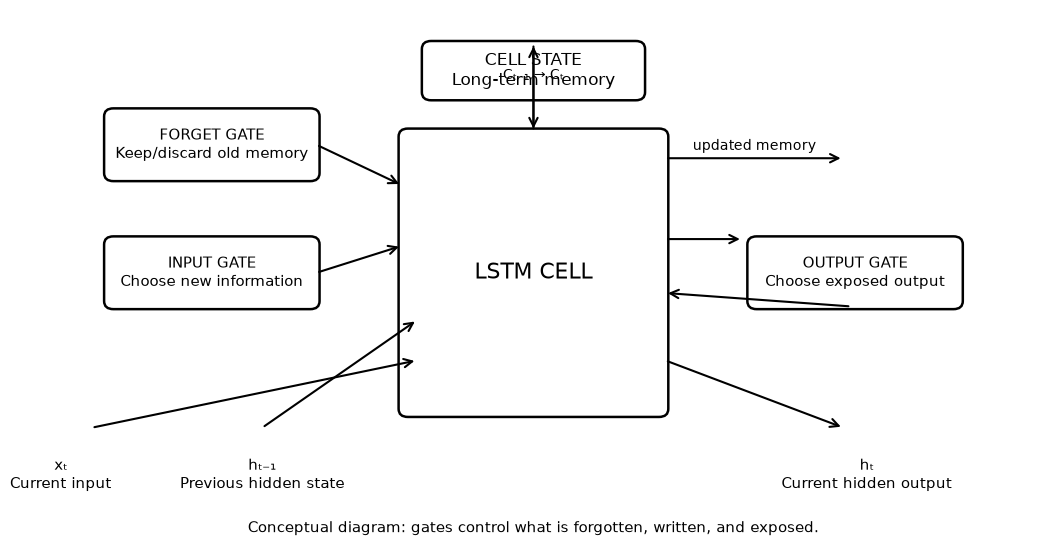

In [5]:
# Draw and label a simple LSTM cell architecture
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 13)
ax.set_ylim(0, 8)
ax.axis("off")

def box(x, y, w, h, text, fontsize=11):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.04,rounding_size=0.12",
        fill=False,
        linewidth=1.8
    )
    ax.add_patch(patch)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center",
            fontsize=fontsize, wrap=True)

def arrow(x1, y1, x2, y2, text=None):
    arr = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="->", mutation_scale=15, linewidth=1.5
    )
    ax.add_patch(arr)
    if text:
        ax.text((x1+x2)/2, (y1+y2)/2 + 0.18, text,
                ha="center", va="center", fontsize=10)

# Main cell
box(4.8, 2.0, 3.4, 4.2, "LSTM CELL", fontsize=16)

# Gates
box(1.0, 5.5, 2.7, 1.0, "FORGET GATE\nKeep/discard old memory")
box(1.0, 3.6, 2.7, 1.0, "INPUT GATE\nChoose new information")
box(9.3, 3.6, 2.7, 1.0, "OUTPUT GATE\nChoose exposed output")

# Cell state
box(5.1, 6.7, 2.8, 0.8, "CELL STATE\nLong-term memory", fontsize=12)

# Inputs/outputs
ax.text(0.4, 1.1, "xₜ\nCurrent input", ha="center", va="center", fontsize=11)
ax.text(3.0, 1.1, "hₜ₋₁\nPrevious hidden state", ha="center", va="center", fontsize=11)
ax.text(10.8, 1.1, "hₜ\nCurrent hidden output", ha="center", va="center", fontsize=11)

# Arrows
arrow(0.8, 1.8, 5.0, 2.8)
arrow(3.0, 1.8, 5.0, 3.4)
arrow(3.7, 6.0, 4.8, 5.4)
arrow(3.7, 4.1, 4.8, 4.5)
arrow(8.2, 4.6, 9.2, 4.6)
arrow(8.2, 5.8, 10.5, 5.8, "updated memory")
arrow(10.6, 3.6, 8.2, 3.8)
arrow(8.2, 2.8, 10.5, 1.8)

# Cell state flow
arrow(6.5, 7.5, 6.5, 6.2, "Cₜ₋₁ → Cₜ")
arrow(6.5, 6.2, 6.5, 7.5)

ax.text(
    6.5, 0.25,
    "Conceptual diagram: gates control what is forgotten, written, and exposed.",
    ha="center", fontsize=11
)

plt.show()


## 4. Information Flow for Zomato Food Orders

Sample order sequence:

`['pizza', 'burger', 'pasta', 'pizza']`

For illustration, we use simple gate values of **0 or 1**:

- `1` = keep/use the information.
- `0` = discard/ignore the information.

This is a conceptual walkthrough, not the actual output of a trained LSTM.

### Time step 1 — `pizza`

Initial memory is assumed to be empty.

| Component | Example value | Meaning |
|---|---:|---|
| Forget gate | 1 | Keep any useful previous memory (there is little/no prior order here). |
| Input gate | 1 | Write information about the current `pizza` order. |
| Output gate | 1 | Expose the useful pizza-related information as the hidden state. |
| Cell state | `pizza` preference | Memory now contains useful information about the first order. |

**Flow:** `pizza → input gate (1) → stored in cell state → output gate (1) → hidden state`

### Time step 2 — `burger`

Now the LSTM receives `burger` while the previous cell state contains information about `pizza`.

| Component | Example value | Meaning |
|---|---:|---|
| Forget gate | 0 | Discard the old pizza-specific memory if it is no longer useful. |
| Input gate | 1 | Store the new burger information. |
| Output gate | 1 | Expose the updated food-preference information. |
| Cell state | `burger` preference | Memory has shifted toward the current useful preference. |

**Flow:** `old pizza memory × 0 → discarded; burger × 1 → stored; output gate 1 → expose updated state.`

In a real model, gate values are continuous numbers between 0 and 1 rather than only 0 or 1. The gates are learned from data.

### Important observation

The later `pasta` and `pizza` orders would continue updating the cell state. Because the sequence contains `pizza` twice, a trained LSTM could potentially learn that pizza is a recurring preference. The actual gates would be learned automatically from many users' order histories.

## 5. What Does “Unrolling an LSTM Through Time” Mean?

Unrolling means showing the same LSTM cell repeatedly for each time step in a sequence.  
For a music playlist app, the LSTM receives Song 1, then Song 2, then Song 3, while carrying its hidden state and cell state forward.  
After seeing the previous songs, it can use the accumulated information to predict which song the user may play next.  
The cell parameters are shared across all time steps; only the states change.